In [789]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [790]:
df=pd.read_csv("Titanic Dataset.csv")


In [791]:
df.isna().count()

,0
PassengerId,891
Survived,891
Pclass,891
Name,891
Sex,891
Age,891
SibSp,891
Parch,891
Ticket,891
Fare,891


In [792]:
df.isnull().count()

,0
PassengerId,891
Survived,891
Pclass,891
Name,891
Sex,891
Age,891
SibSp,891
Parch,891
Ticket,891
Fare,891


In [793]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [794]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [795]:
df['Age']

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [796]:
df['Age'].unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  ,
       16.  , 25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  ,
       71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 ,
       51.  , 55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

In [797]:
df['Age'].mean()

np.float64(29.69911764705882)

In [798]:
df['Age'].median()

28.0

<Axes: ylabel='Age'>

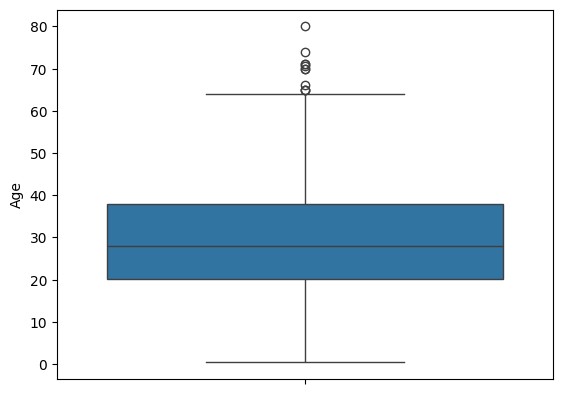

In [799]:
sns.boxplot(df['Age'])

In [800]:
df['Age']=df['Age'].mask(df['Age']>60,60)

In [801]:
df['Age']=df['Age'].fillna(df['Age'].mean())

<Axes: ylabel='Age'>

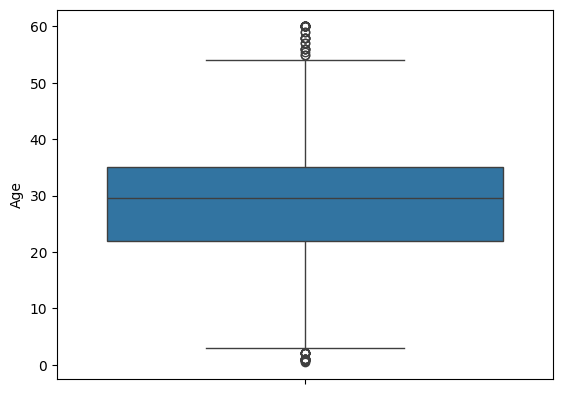

In [824]:
sns.boxplot(df['Age'])

In [802]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [803]:
df=df.drop(['Name','PassengerId','Ticket','Cabin'],axis=1)

In [804]:
nv=df['Embarked'].mode()
nv

,Embarked
0,S


In [805]:
df['Embarked']=df['Embarked'].fillna(nv[0])

In [806]:
df.shape

(891, 8)

In [807]:
df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [808]:
df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.000000,1,0,7.2500,S
1,1,1,female,38.000000,1,0,71.2833,C
2,1,3,female,26.000000,0,0,7.9250,S
3,1,1,female,35.000000,1,0,53.1000,S
4,0,3,male,35.000000,0,0,8.0500,S
5,0,3,male,29.513543,0,0,8.4583,Q
6,0,1,male,54.000000,0,0,51.8625,S
7,0,3,male,2.000000,3,1,21.0750,S
8,1,3,female,27.000000,0,2,11.1333,S
9,1,2,female,14.000000,1,0,30.0708,C


In [809]:
df['Sex']=df['Sex'].map({'male':1,'female':0})

In [810]:
df=pd.get_dummies(df,dtype=int)

In [811]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0,0,1
1,1,1,0,38.0,1,0,71.2833,1,0,0
2,1,3,0,26.0,0,0,7.9250,0,0,1
3,1,1,0,35.0,1,0,53.1000,0,0,1
4,0,3,1,35.0,0,0,8.0500,0,0,1


In [812]:
corr_data=df.corr()
corr_data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
Survived,1.000000,-0.338481,-0.543351,-0.067724,-0.035322,0.081629,0.257307,0.168240,0.003650,-0.149683
Pclass,-0.338481,1.000000,0.131900,-0.333762,0.083081,0.018443,-0.549500,-0.243292,0.221009,0.074053
Sex,-0.543351,0.131900,1.000000,0.079357,-0.114631,-0.245489,-0.182333,-0.082853,-0.074115,0.119224
Age,-0.067724,-0.333762,0.079357,1.000000,-0.236115,-0.182158,0.094102,0.032417,-0.017579,-0.017335
SibSp,-0.035322,0.083081,-0.114631,-0.236115,1.000000,0.414838,0.159651,-0.059528,-0.026354,0.068734
Parch,0.081629,0.018443,-0.245489,-0.182158,0.414838,1.000000,0.216225,-0.011069,-0.081228,0.060814
Fare,0.257307,-0.549500,-0.182333,0.094102,0.159651,0.216225,1.000000,0.269335,-0.117216,-0.162184
Embarked_C,0.168240,-0.243292,-0.082853,0.032417,-0.059528,-0.011069,0.269335,1.000000,-0.148258,-0.782742
Embarked_Q,0.003650,0.221009,-0.074115,-0.017579,-0.026354,-0.081228,-0.117216,-0.148258,1.000000,-0.499421
Embarked_S,-0.149683,0.074053,0.119224,-0.017335,0.068734,0.060814,-0.162184,-0.782742,-0.499421,1.000000


<Axes: >

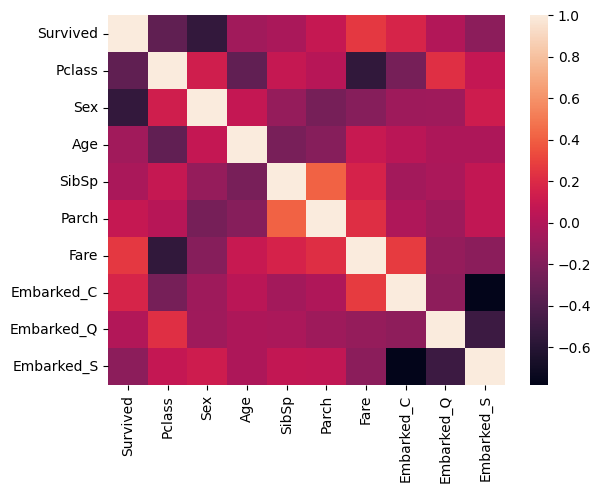

In [813]:
sns.heatmap(corr_data)

In [814]:
df.shape

(891, 10)

In [815]:
X=df.drop('Survived',axis=1)
y=df['Survived']

In [816]:
from sklearn.model_selection import train_test_split

In [817]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [818]:
from sklearn.linear_model import LogisticRegression

In [819]:
model=LogisticRegression()

In [820]:
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [821]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8135593220338984

In [822]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[153,  22],
       [ 33,  87]])

<Axes: >

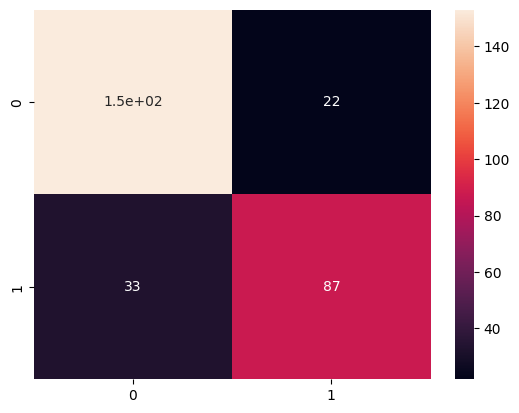

In [823]:
sns.heatmap(cm,annot=True)